# Unemployment Analysis with Python
**CodeAlpha Data Science Internship - Task 2**

Goal: explore unemployment-rate trends, the impact of Covid-19, regional differences and seasonality.

Place the unemployment CSV (e.g. `Unemployment in India.csv`) in the same folder as this notebook.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

files = glob.glob("*nemploy*.csv") + glob.glob("**/*nemploy*.csv", recursive=True)
print("Found:", files)
df = pd.read_csv(files[0])
print("Using:", files[0])
df.head()

Found: ['Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv', 'Unemployment_Rate_upto_11_2020.csv']
Using: Unemployment in India.csv


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 1. Cleaning

In [2]:
df.columns = df.columns.str.strip()
print(df.shape)
print("Missing values:\n", df.isnull().sum())
df = df.dropna().drop_duplicates().reset_index(drop=True)

# Rename long columns
rate = [c for c in df.columns if "unemployment" in c.lower()][0]
employed = [c for c in df.columns if "employed" in c.lower() and "un" not in c.lower()][0]
lpr = [c for c in df.columns if "participation" in c.lower()][0]
df = df.rename(columns={rate: "Unemployment_Rate", employed: "Employed", lpr: "Labour_Participation"})

df["Date"] = pd.to_datetime(df["Date"].astype(str).str.strip(), dayfirst=True)
df["Region"] = df["Region"].str.strip()
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")
df["Year"] = df["Date"].dt.year
print("Date range:", df["Date"].min().date(), "->", df["Date"].max().date())
df.describe()

(768, 7)
Missing values:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Date range: 2019-05-31 -> 2020-06-30


,Date,Unemployment_Rate,Employed,Labour_Participation,Month,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


## 2. National trend over time

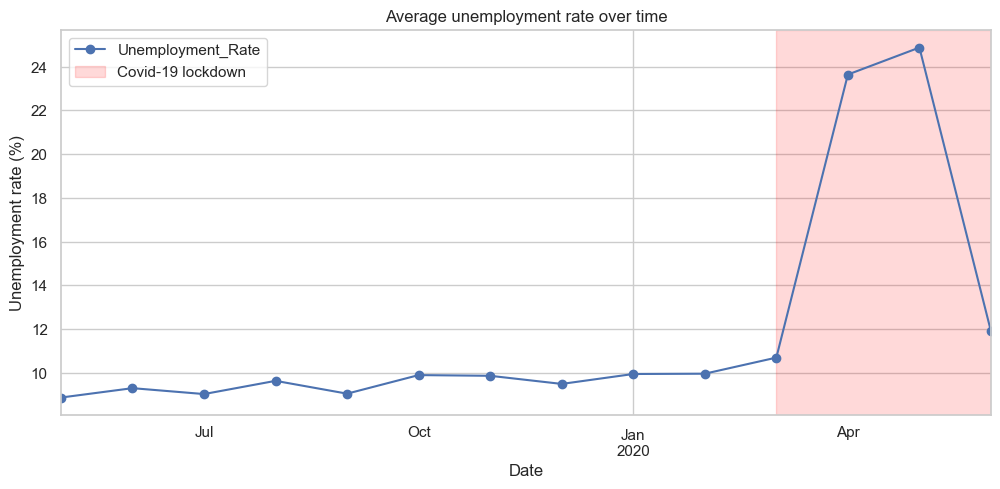

In [3]:
national = df.groupby("Date")["Unemployment_Rate"].mean()
ax = national.plot(marker="o", title="Average unemployment rate over time")
ax.axvspan(pd.Timestamp("2020-03-25"), pd.Timestamp("2020-06-30"), color="red", alpha=0.15, label="Covid-19 lockdown")
ax.set_ylabel("Unemployment rate (%)")
ax.legend()
plt.show()

## 3. Impact of Covid-19

Average before Covid : 9.51%
Average during Covid : 17.77%
Increase             : 8.26 percentage points
Peak month: May 2020 (24.88%)


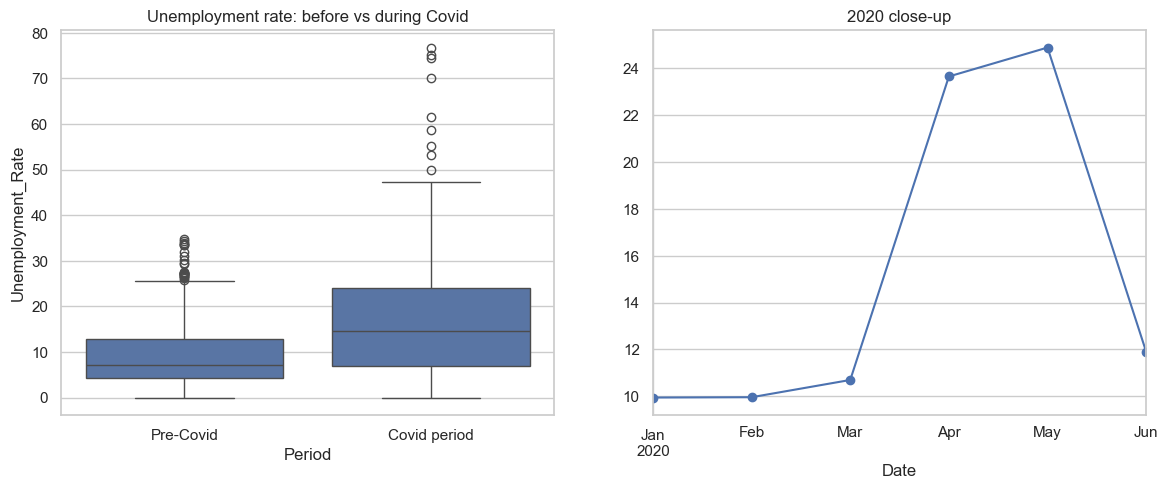

In [4]:
df["Period"] = np.where(df["Date"] < "2020-03-01", "Pre-Covid", "Covid period")
pre = df[df["Period"] == "Pre-Covid"]["Unemployment_Rate"].mean()
post = df[df["Period"] == "Covid period"]["Unemployment_Rate"].mean()
print(f"Average before Covid : {pre:.2f}%")
print(f"Average during Covid : {post:.2f}%")
print(f"Increase             : {post - pre:.2f} percentage points")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Period", y="Unemployment_Rate", order=["Pre-Covid", "Covid period"], ax=axes[0])
axes[0].set_title("Unemployment rate: before vs during Covid")
peak = national.idxmax()
print(f"Peak month: {peak.strftime('%B %Y')} ({national.max():.2f}%)")
national.loc["2020-01-01":].plot(marker="o", ax=axes[1], title="2020 close-up")
plt.show()

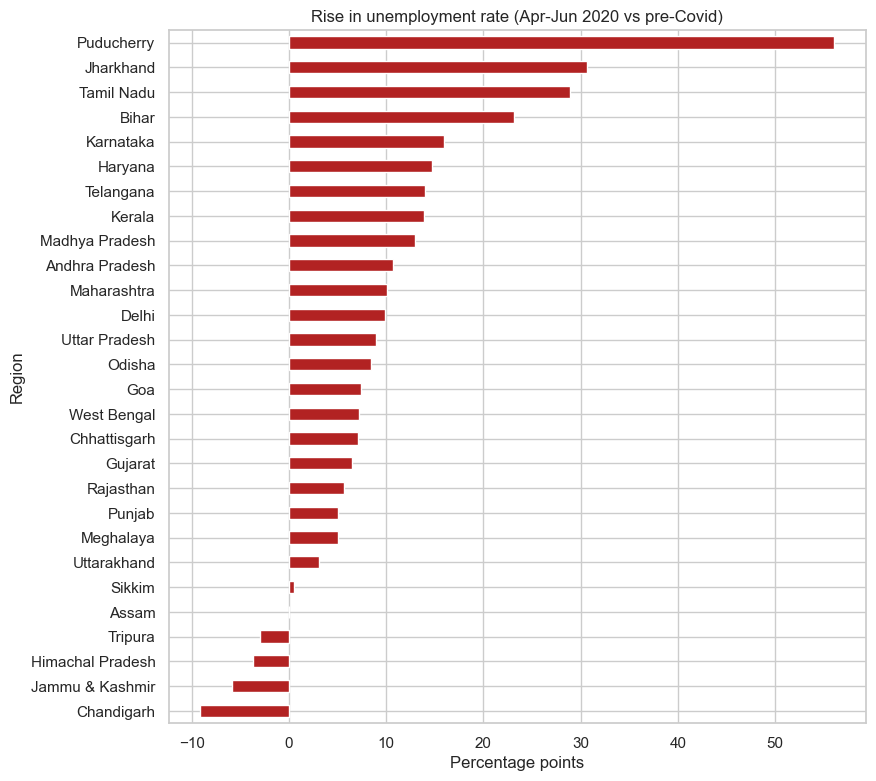

Hardest hit: ['Puducherry', 'Jharkhand', 'Tamil Nadu', 'Bihar', 'Karnataka']


In [5]:
# Which regions were hit hardest? Compare Apr-Jun 2020 vs pre-Covid average
pre_r = df[df["Period"] == "Pre-Covid"].groupby("Region")["Unemployment_Rate"].mean()
peak_r = df[(df["Date"] >= "2020-04-01") & (df["Date"] <= "2020-06-30")].groupby("Region")["Unemployment_Rate"].mean()
impact = (peak_r - pre_r).dropna().sort_values()
impact.plot(kind="barh", figsize=(9, 9), color="firebrick", title="Rise in unemployment rate (Apr-Jun 2020 vs pre-Covid)")
plt.xlabel("Percentage points")
plt.show()
print("Hardest hit:", list(impact.tail(5).index[::-1]))

## 4. Regional comparison

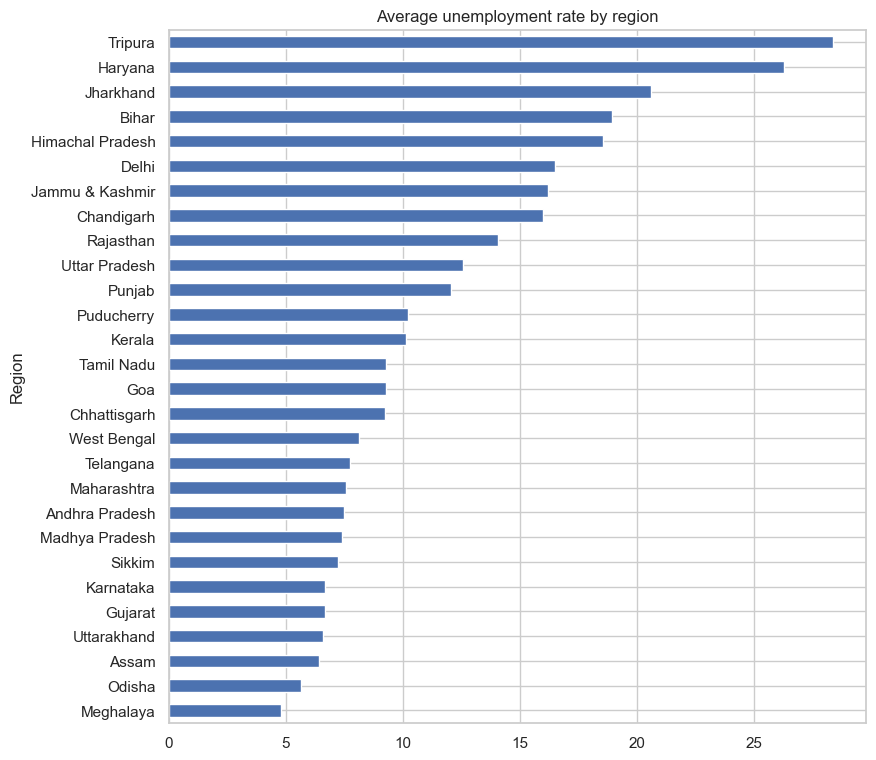

Highest: {'Jharkhand': 20.58, 'Haryana': 26.28, 'Tripura': 28.35}
Lowest : {'Meghalaya': 4.8, 'Odisha': 5.66, 'Assam': 6.43}


In [6]:
reg = df.groupby("Region")["Unemployment_Rate"].mean().sort_values()
reg.plot(kind="barh", figsize=(9, 9), title="Average unemployment rate by region")
plt.show()
print("Highest:", reg.tail(3).round(2).to_dict())
print("Lowest :", reg.head(3).round(2).to_dict())

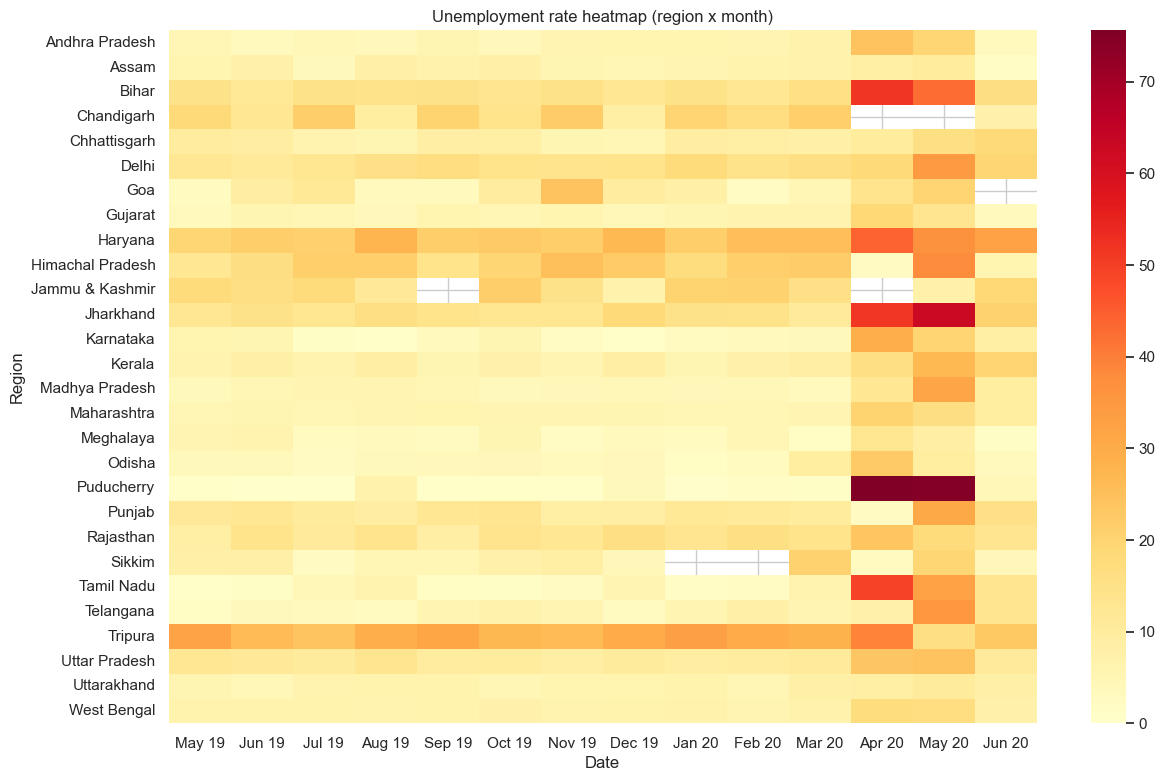

In [7]:
pivot = df.pivot_table(index="Region", columns="Date", values="Unemployment_Rate")
plt.figure(figsize=(14, 9))
sns.heatmap(pivot, cmap="YlOrRd", xticklabels=[d.strftime("%b %y") for d in pivot.columns])
plt.title("Unemployment rate heatmap (region x month)")
plt.show()

## 5. Seasonal patterns (pre-Covid data only)

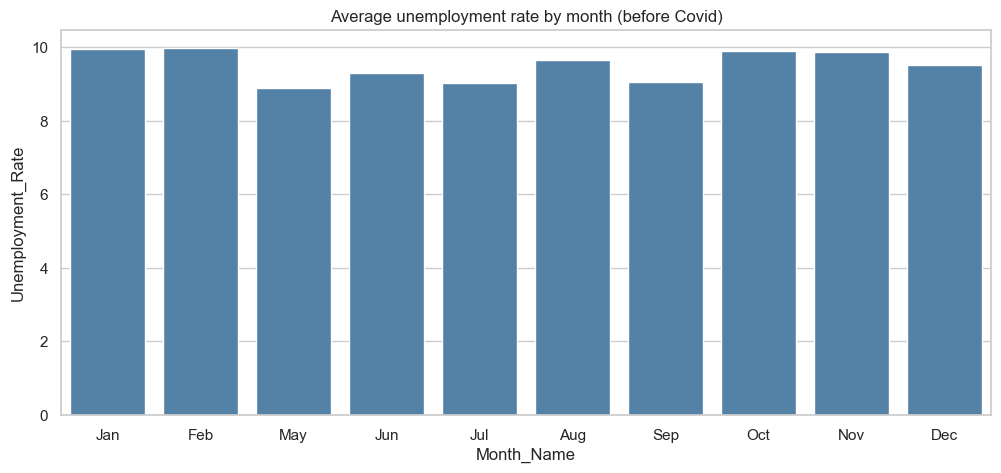

In [8]:
pre_df = df[df["Period"] == "Pre-Covid"]
season = pre_df.groupby(["Month", "Month_Name"])["Unemployment_Rate"].mean().reset_index().sort_values("Month")
sns.barplot(data=season, x="Month_Name", y="Unemployment_Rate", color="steelblue")
plt.title("Average unemployment rate by month (before Covid)")
plt.show()

## 6. Relationships between indicators

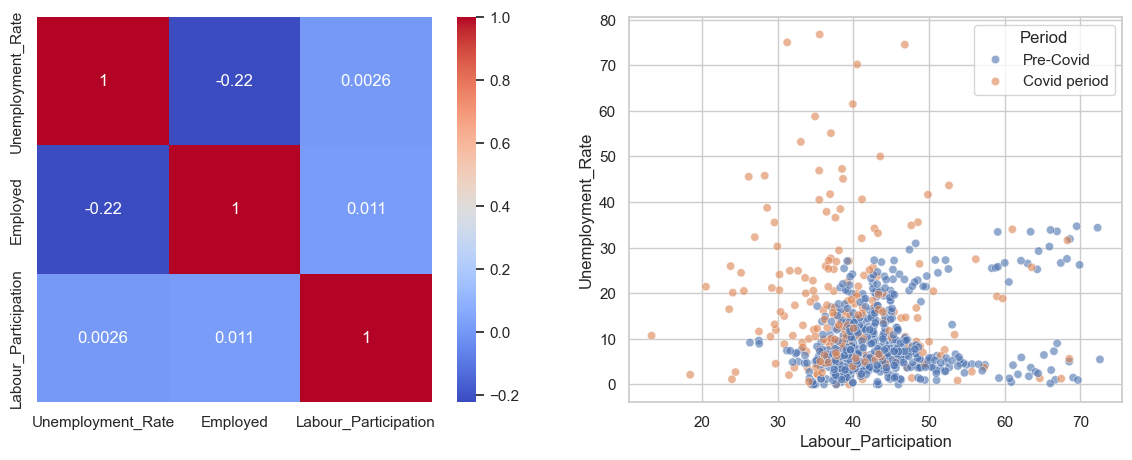

In [9]:
num_cols = ["Unemployment_Rate", "Employed", "Labour_Participation"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", ax=axes[0])
sns.scatterplot(data=df, x="Labour_Participation", y="Unemployment_Rate", hue="Period", alpha=0.6, ax=axes[1])
plt.show()

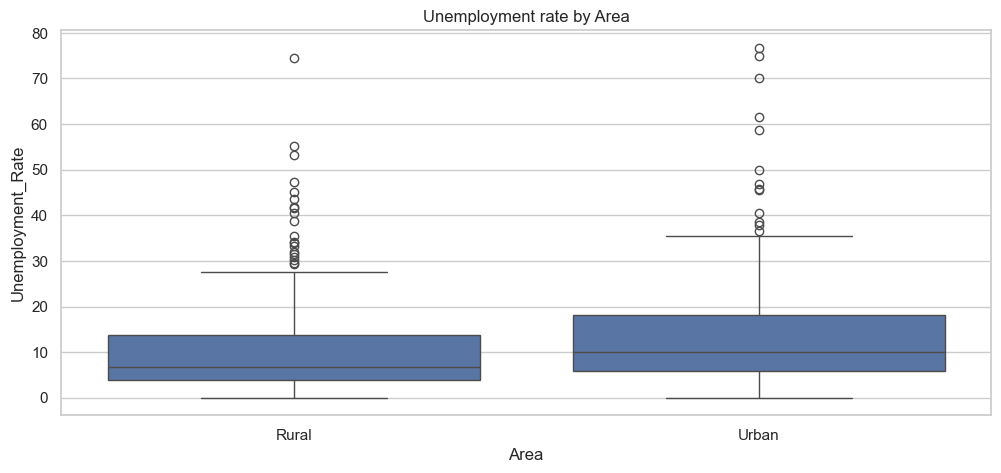

In [10]:
if "Area" in df.columns or "Frequency" in df.columns:
    grp = "Area" if "Area" in df.columns else "Frequency"
    sns.boxplot(data=df, x=grp, y="Unemployment_Rate")
    plt.title(f"Unemployment rate by {grp}")
    plt.show()
else:
    print("No Area/Frequency column in this file - skipping.")

## Key insights
1. **Covid-19 shock:** the national unemployment rate jumped sharply in April-May 2020 during the lockdown, far above its pre-Covid level, then began to recover.
2. **Regional differences:** some regions were hit much harder than others (see the regional impact chart); densely industrialised or urban regions saw the biggest spikes.
3. **Structural gaps:** a few regions have persistently higher unemployment even before Covid, pointing to long-term structural problems.
4. **Seasonality:** unemployment shows mild month-to-month variation before Covid, linked to agricultural and harvest cycles.
5. **Policy suggestions:** target employment support and job-guarantee schemes at the hardest-hit and persistently high-unemployment regions; build faster safety nets (cash transfers, wage support) for sudden shocks; and invest in skills training to improve labour participation.